# Task 3 Analysis: Training Variational Autoencoders

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from architecture import VAE
from vae_utils import plot_reconstructions, plot_generations, plot_training_curves, sample_latents

# Setup Device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

Using device: mps


### Prerequisites
Before running the cells below, you **must** train both the baseline and mitigated models using the command line:

1.  **Train Baseline:**
    ```bash
    python train_vae.py --mode baseline --epochs 30
    ```
2.  **Train Mitigated:**
    ```bash
    python train_vae.py --mode mitigated --epochs 30
    ```

This ensures the model weights (`models/*.pth`) and training logs (`outputs/losses/*.json`) exist.

In [5]:
# Load test set for visualizing reconstructions
transform = transforms.ToTensor()
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True)
print(f"Test dataset size: {len(test_dataset)}")

# Helper function to load models
def load_vae(path, device):
    if not os.path.exists(path):
        print(f"Error: Model not found at {path}. Run the training script first.")
        return None
    model = VAE(input_dim=784, hidden_dim=400, latent_dim=20)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

print("Loading Baseline Model...")
baseline_model = load_vae('models/vae_baseline.pth', device)

Test dataset size: 10000
Loading Baseline Model...


## 3.2 (a) Visualize Reconstructions and Generations

We compare original test images with their reconstructions. Good reconstructions imply the Encoder captured information and the Decoder learned to map it back.

Baseline Reconstructions (Top: Original, Bottom: Reconstructed)
Saved reconstructions to outputs/reconstructions/baseline_reconstructions.png


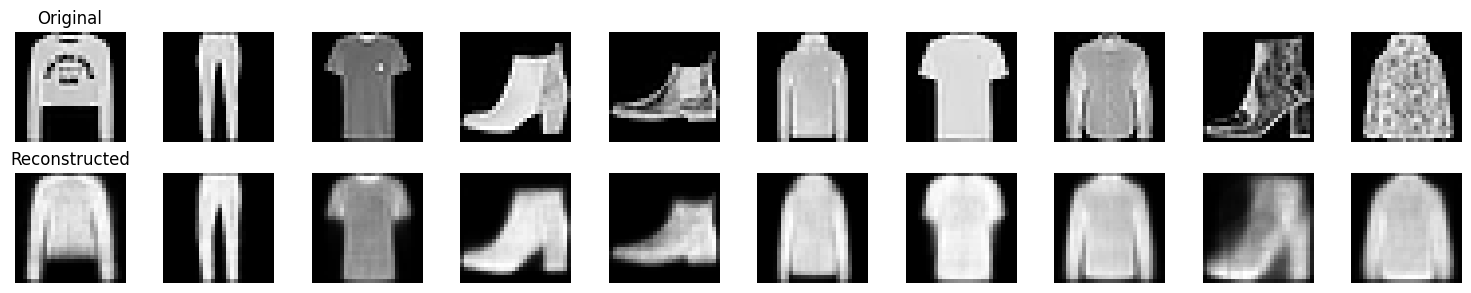

In [6]:
if baseline_model:
    print("Baseline Reconstructions (Top: Original, Bottom: Reconstructed)")
    plot_reconstructions(
        baseline_model, 
        test_loader, 
        device, 
        num_images=10,
        save_path='outputs/reconstructions/baseline_reconstructions.png'
    )

## **3.2 (b) & (c) Visualize Generations (Gaussian vs Laplacian)**
We sample $z$ from the prior distribution $p(z)$ and decode it. 
- **Gaussian:** The standard prior we trained on.
- **Laplacian:** A different distribution to test robustness.

Generations from Standard Normal Prior N(0, I):
Saved generations to outputs/generations/baseline_generations_gaussian.png


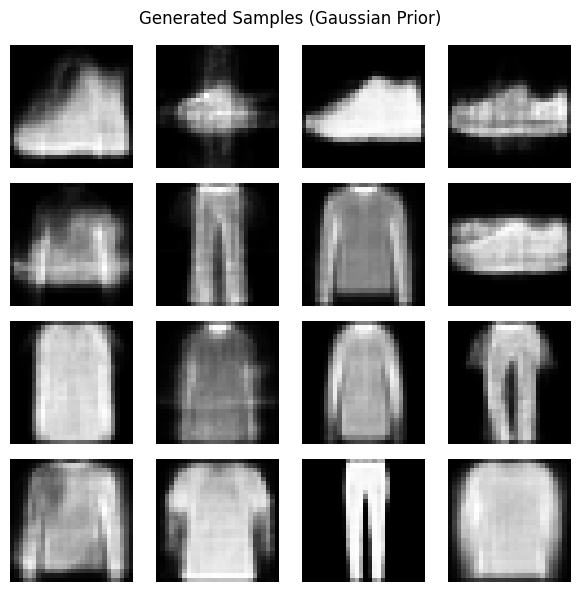

Generations from Laplacian Prior:
Saved generations to outputs/generations/baseline_generations_laplace.png


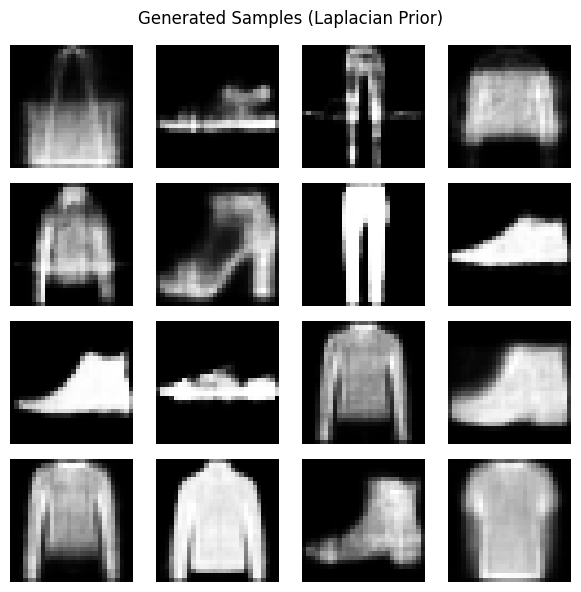

In [7]:
if baseline_model:
    # 3.2(b) Gaussian Prior Generations
    print("Generations from Standard Normal Prior N(0, I):")
    plot_generations(
        baseline_model, 
        latent_dim=20, 
        num_samples=16, 
        device=device, 
        dist='normal', 
        save_path='outputs/generations/baseline_generations_gaussian.png'
    )
    
    # 3.2(c) Laplacian Prior Generations
    print("Generations from Laplacian Prior:")
    plot_generations(
        baseline_model, 
        latent_dim=20, 
        num_samples=16, 
        device=device, 
        dist='laplace', 
        save_path='outputs/generations/baseline_generations_laplace.png'
    )

### Task 3.2(d): Observations - Gaussian vs Laplacian Prior

**Observations:**

1. **Gaussian Prior (N(0, I))**: Since the VAE is trained with a Gaussian prior, samples from this distribution are expected to produce the best-quality generations.

2. **Laplacian Prior (Laplace(0, 1))**: The Laplacian distribution has heavier tails than the Gaussian. This means:
   - Some latent samples will be further from the origin
   - These out-of-distribution samples may produce blurrier or more distorted outputs
   - The decoder hasn't learned to handle these extreme latent values

3. **Reconstructions vs Generations**:
   - Reconstructions should look sharper because they use encoder outputs (learned representations)
   - Generations sample from the prior and may explore regions the encoder never visits
   - With posterior collapse, both may look similar (blurry "blobs")

## 3.3: Posterior Collapse Investigation

Saved curves to outputs/losses/baseline_training_curves.png


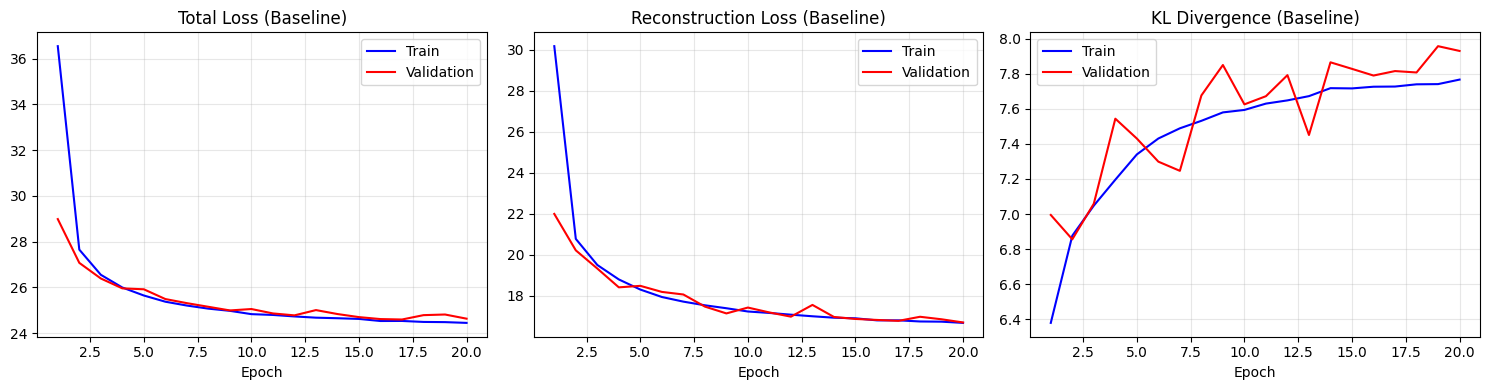

Final Baseline KL Divergence: 7.76634


In [8]:
# Load history files
def load_history(path):
    if os.path.exists(path):
        with open(path, 'r') as f:
            return json.load(f)
    return None

baseline_hist = load_history('outputs/losses/history_baseline.json')

if baseline_hist:
    # Plot all curves
    plot_training_curves(
        baseline_hist, 
        save_path='outputs/losses/baseline_training_curves.png',
        title_suffix='(Baseline)'
    )
    
    # Specific check for KL Divergence magnitude
    final_kl = baseline_hist['train_kl_loss'][-1]
    print(f"Final Baseline KL Divergence: {final_kl:.5f}")

## Part 4: Mitigating Posterior Collapse

We now load the model trained with **KL Annealing** (Task 3.4). We expect this model to have higher KL divergence and sharper, more diverse generations.

In [9]:
print("Loading Mitigated Model...")
mitigated_model = load_vae('models/vae_mitigated.pth', device)
mitigated_hist = load_history('outputs/losses/history_mitigated.json')

Loading Mitigated Model...


Mitigated Reconstructions:
Saved reconstructions to outputs/reconstructions/mitigated_reconstructions.png


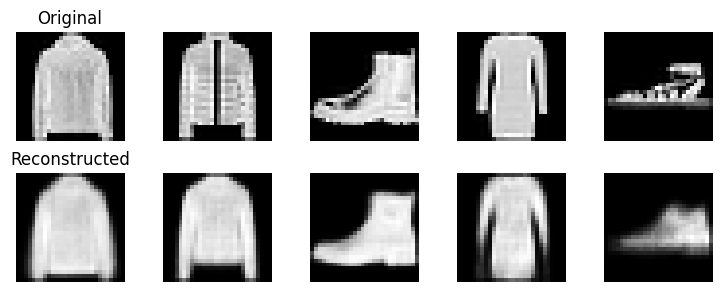

Mitigated Generations (Gaussian Prior):
Saved generations to outputs/generations/mitigated_generations_gaussian.png


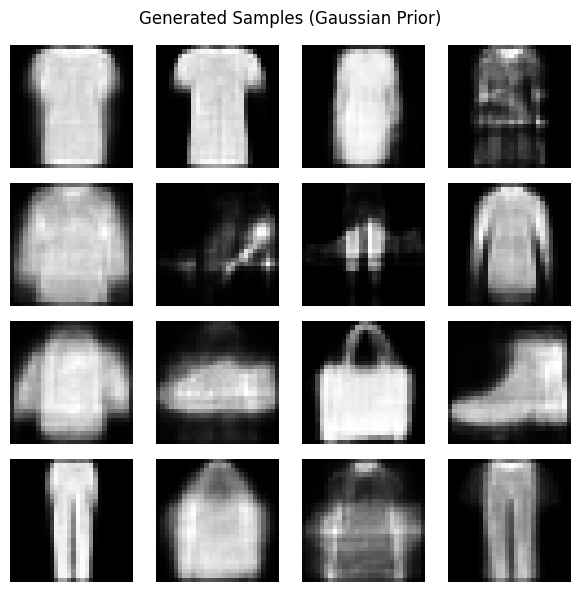

In [10]:
if mitigated_model:
    # 3.4(c) Mitigated Reconstructions
    print("Mitigated Reconstructions:")
    plot_reconstructions(
        mitigated_model, 
        test_loader, 
        device, 
        num_images=5,
        save_path='outputs/reconstructions/mitigated_reconstructions.png'
    )
    
    # 3.4(c) Mitigated Generations
    print("Mitigated Generations (Gaussian Prior):")
    plot_generations(
        mitigated_model, 
        latent_dim=20, 
        num_samples=16, 
        device=device, 
        dist='normal',
        save_path='outputs/generations/mitigated_generations_gaussian.png'
    )

### Comparison: Baseline vs. Mitigated
Here we explicitly compare the KL divergence curves to show the effect of annealing.

Saved comparison plot to outputs/losses/kl_comparison.png


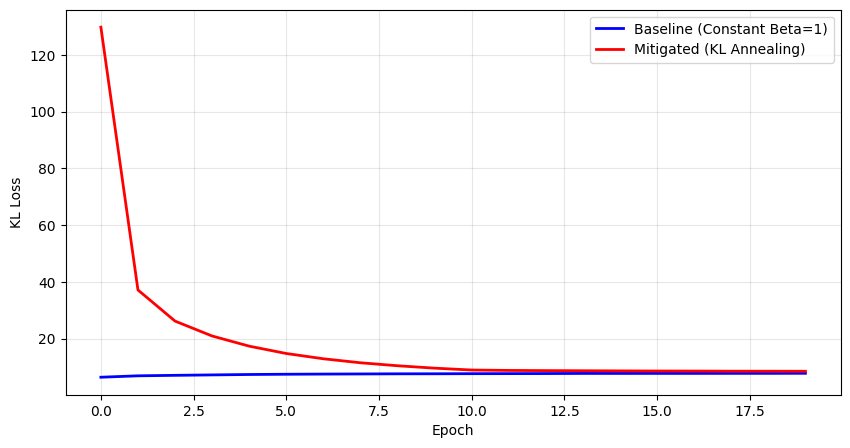

In [11]:
if baseline_hist and mitigated_hist:
    plt.figure(figsize=(10, 5))
    
    # Plot KL Divergence Comparison
    plt.plot(baseline_hist['train_kl_loss'], label='Baseline (Constant Beta=1)', linewidth=2, color='blue')
    plt.plot(mitigated_hist['train_kl_loss'], label='Mitigated (KL Annealing)', linewidth=2, color='red')
    
    plt.xlabel('Epoch')
    plt.ylabel('KL Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    save_path = 'outputs/losses/kl_comparison.png'
    plt.savefig(save_path, bbox_inches='tight')
    print(f"Saved comparison plot to {save_path}")
    plt.show()